In [36]:
# 0
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
 
student_name = "Ian Marlo S. Ganal" 
student_id = "2025-0519"  
 
id_num = int(student_id[-3:]) 
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) 
% 256:02x}" 
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) 
% 256:02x}" 

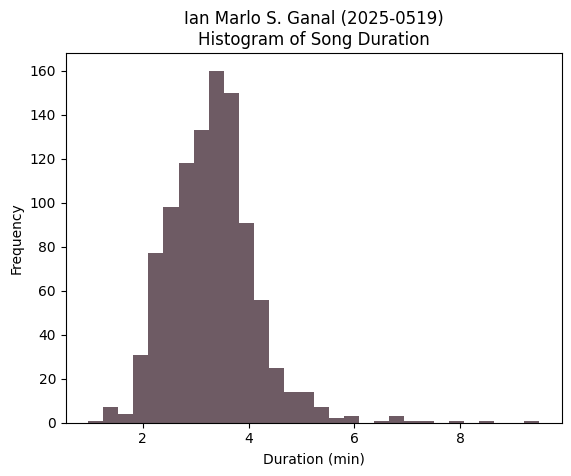

In [37]:
# 1
csv_files = r"C:\Users\Admin\Desktop\GANAL\Lab7\spotify_top_1000_tracks.csv"

df = pd.read_csv(csv_files)

df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\407272902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


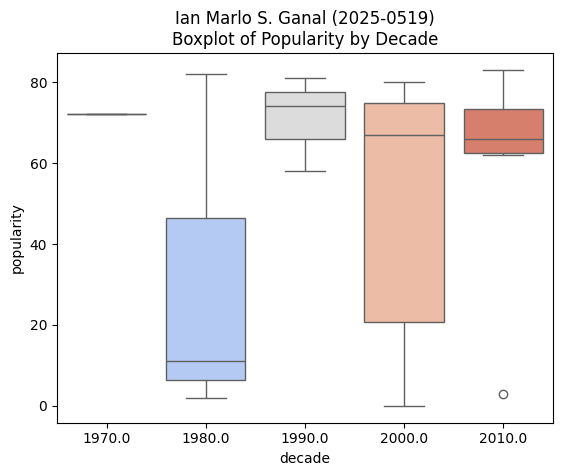

In [38]:
# 2
# Convert release_date to numeric (integers), ignoring errors if there are empty values
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')

df['decade'] = (df['release_date'] // 10) * 10 
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade") 
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\840096045.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


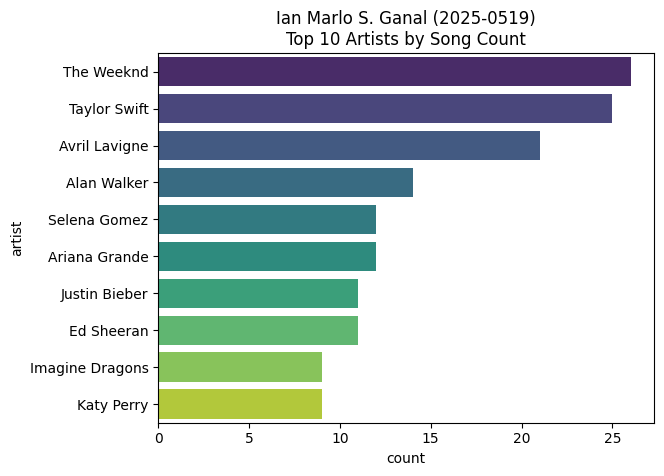

In [39]:
# 3
sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\1906824309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',
C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\1906824309.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',


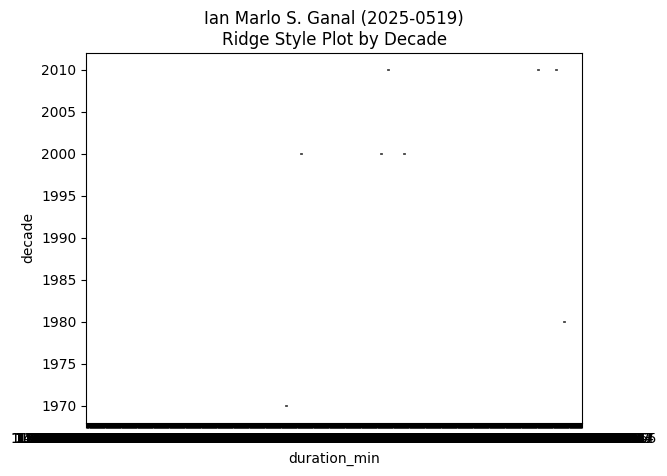

In [40]:
# 4
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', 
scale='width') 
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade") 
plt.show() 


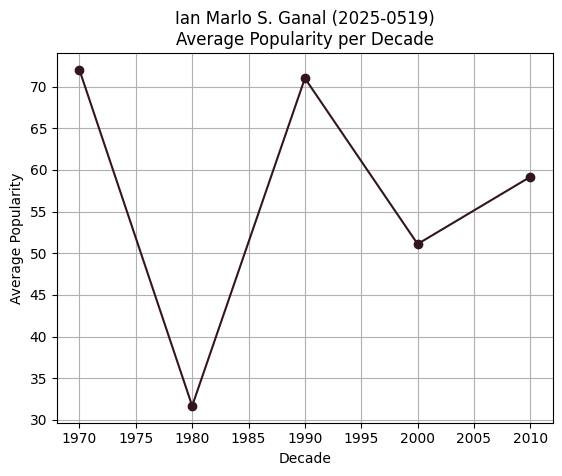

In [41]:
# 5
avg_pop = df.groupby('decade')['popularity'].mean() 
avg_pop.plot(kind='line', color=color1, marker='o') 
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade") 
plt.xlabel('Decade') 
plt.ylabel('Average Popularity') 
plt.grid(True) 
plt.show()


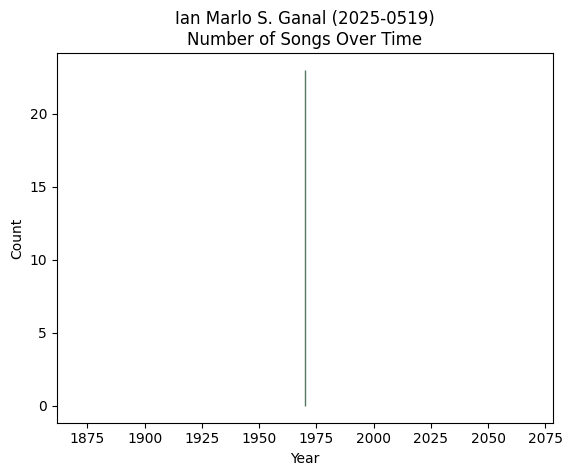

In [42]:
# 6
df['release_year'] = pd.to_datetime(df['release_date'], 
errors='coerce').dt.year 
count_by_year = df['release_year'].value_counts().sort_index() 
count_by_year.plot(kind='area', color=color2, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time") 
plt.xlabel('Year') 
plt.ylabel('Count') 
plt.show()


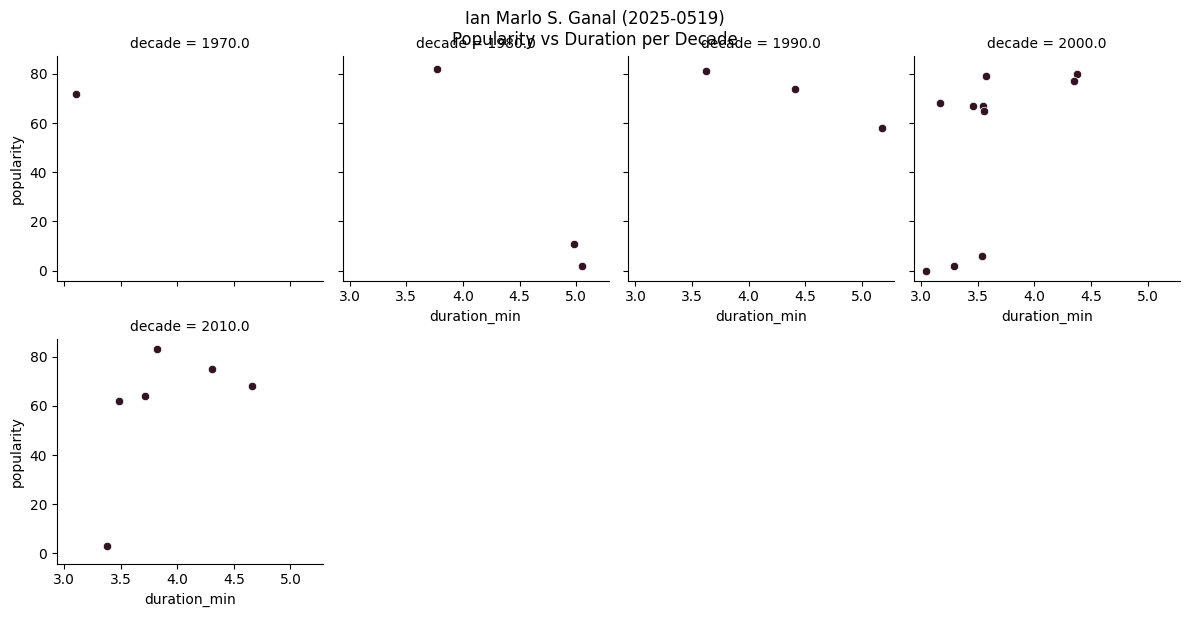

In [43]:
# 7

g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', 
color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show()

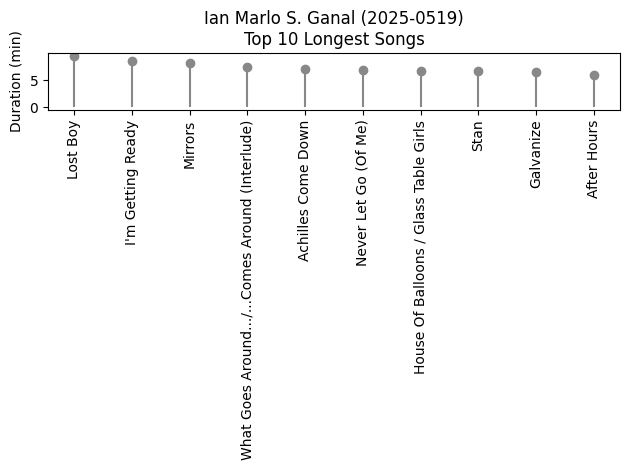

In [44]:
# 8
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 


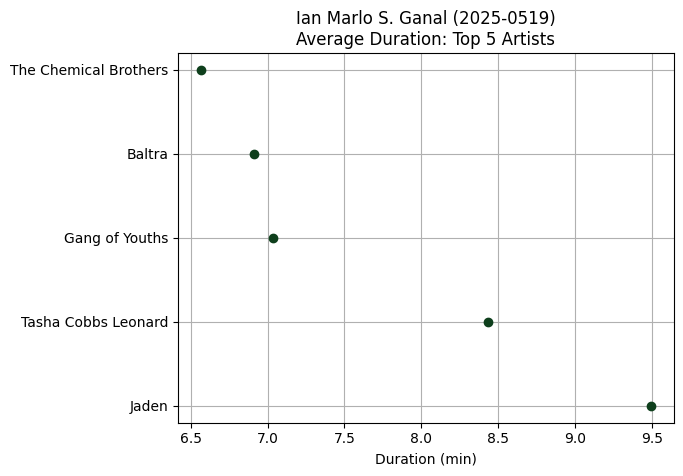

In [45]:
# 9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show()

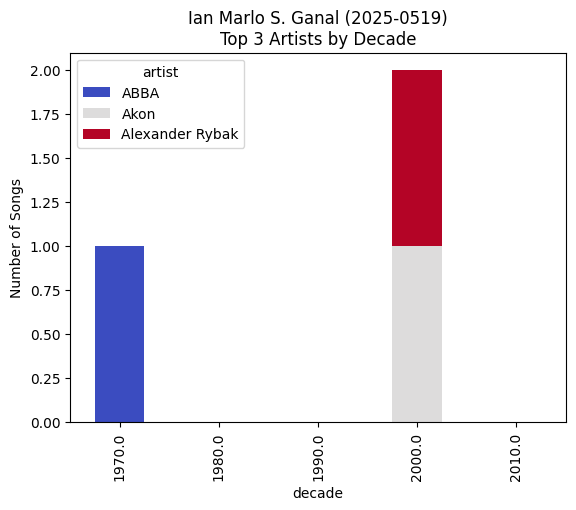

In [46]:
# 10
crosstab = pd.crosstab(df['decade'], df['artist'])

top3 = crosstab.sum().sort_values(ascending=False).head(3).index

crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm')

plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade")
plt.ylabel('Number of Songs')
plt.show()

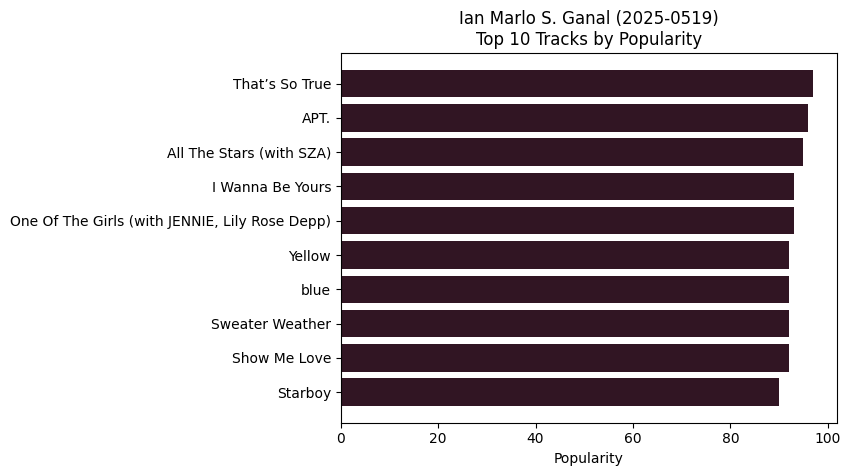

In [47]:
# 11
top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\4180083212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\4180083212.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


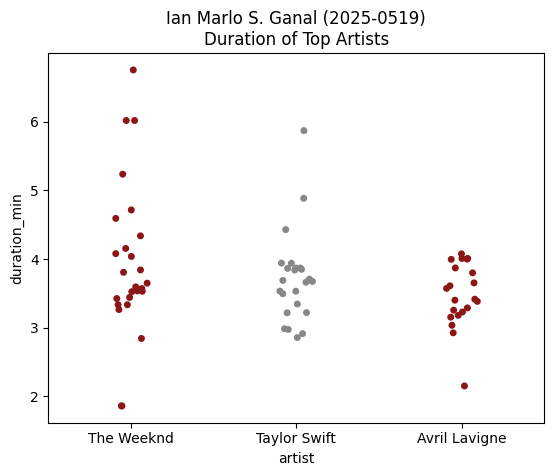

In [48]:
# 12
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show() 

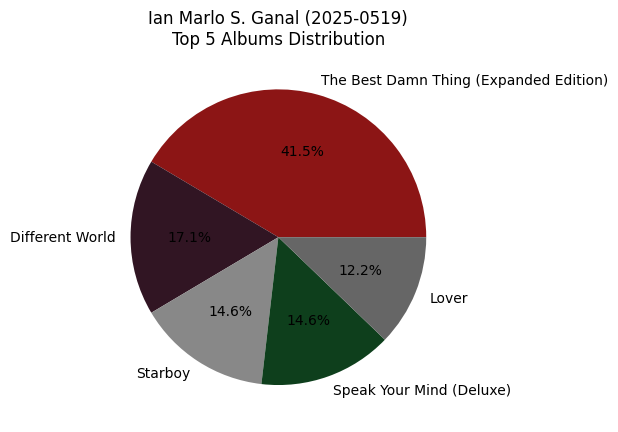

In [49]:
# 13
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show() 

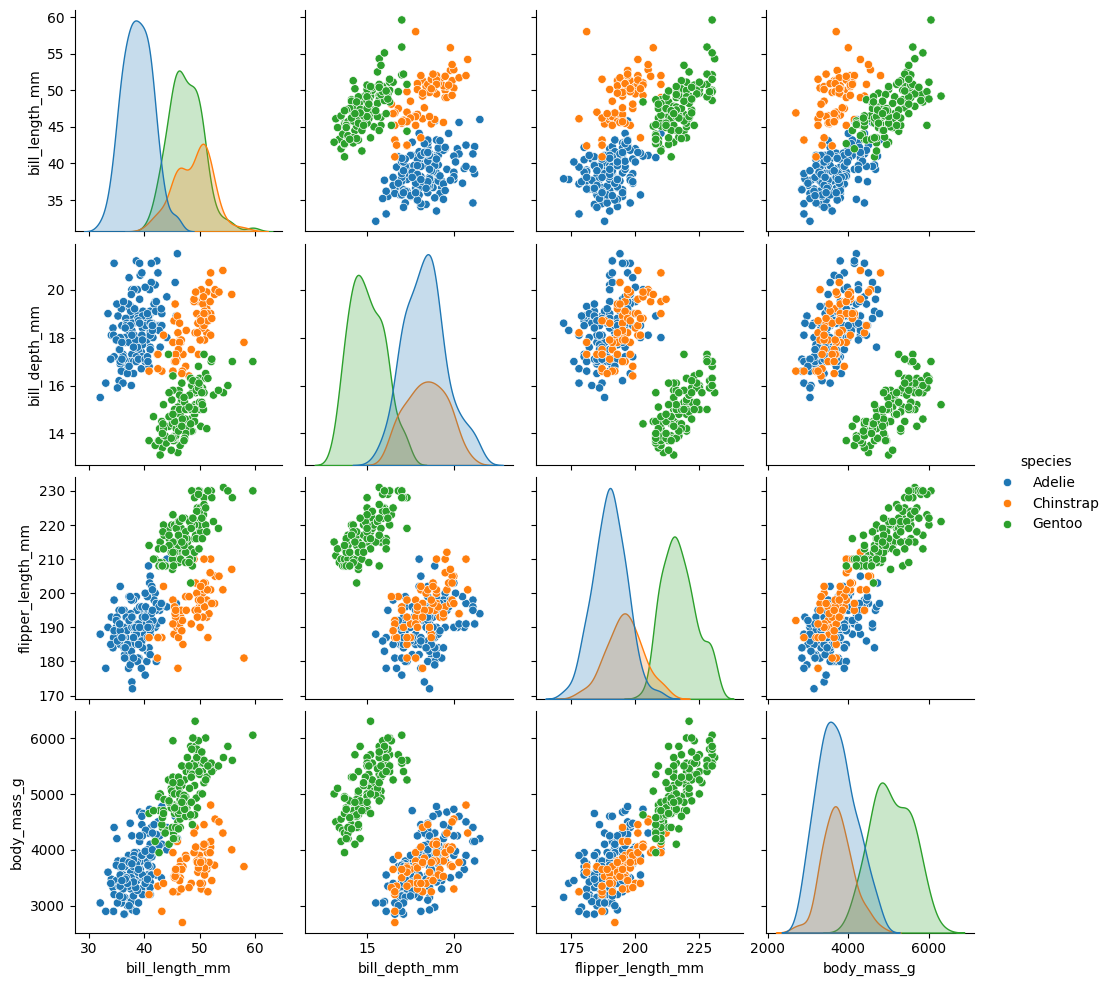

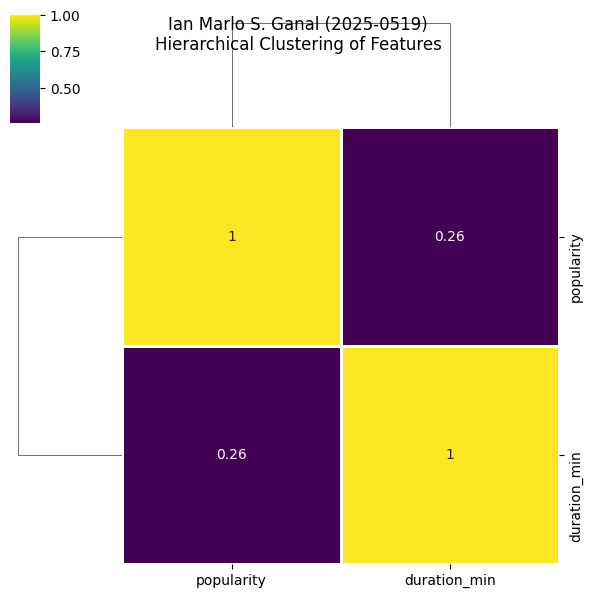

In [50]:
# 14
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("penguins")
sns.pairplot(df, hue="species")

student_name = "Ian Marlo S. Ganal" 
student_id = "2025-0519"  

df = pd.read_csv('spotify_top_1000_tracks.csv')

numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show() 

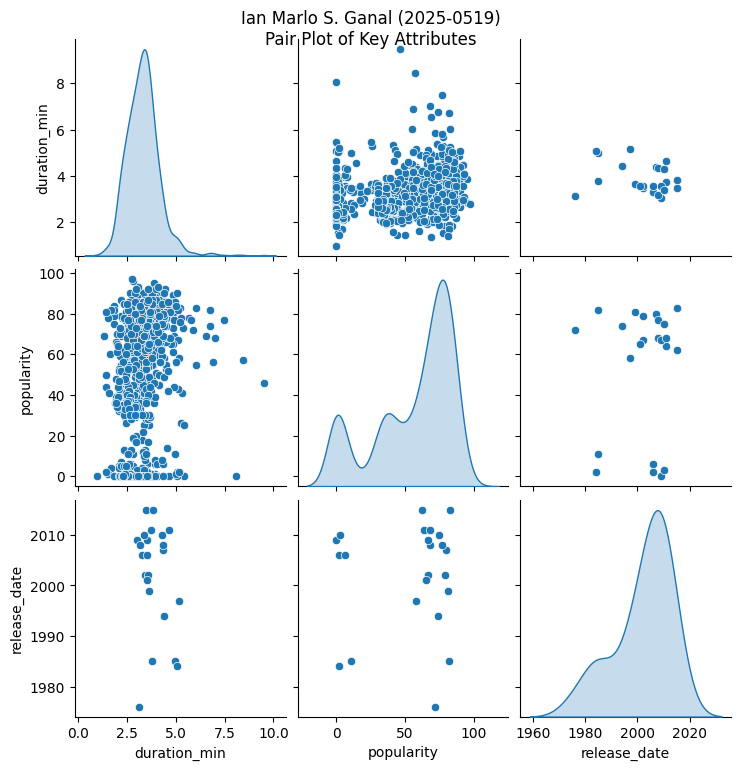

In [51]:
# 15
import seaborn as sns
import matplotlib.pyplot as plt

student_name = "Ian Marlo S. Ganal" 
student_id = "2025-0519"  

df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')

sns.pairplot(df[['duration_min', 'popularity', 'release_date']], diag_kind='kde') 
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02) 
plt.show()


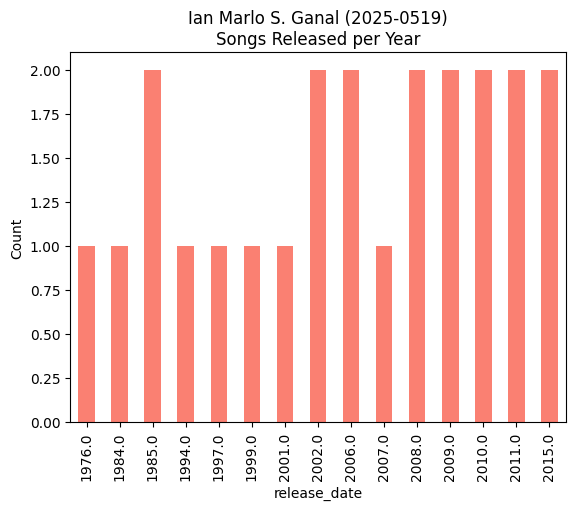

In [52]:
# 16
color1 = 'skyblue'
color2 = 'salmon'

df['release_date'].value_counts().sort_index().plot(kind='bar', color=color2) 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_1096\2108398401.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm')


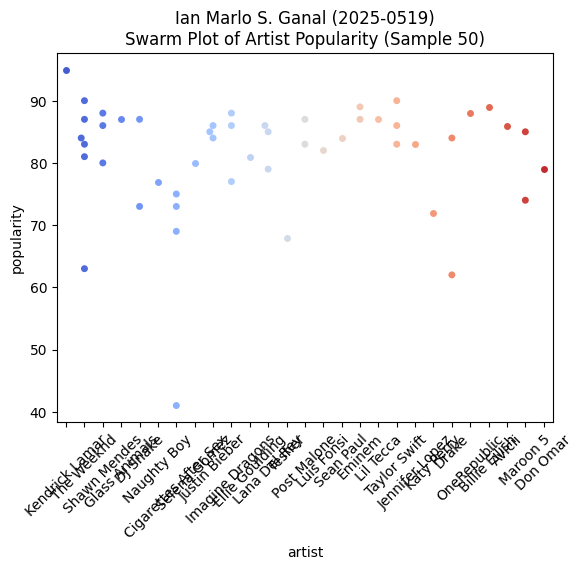

In [53]:
# 17
sns.swarmplot(data=df.head(50), x='artist', y='popularity', palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show()

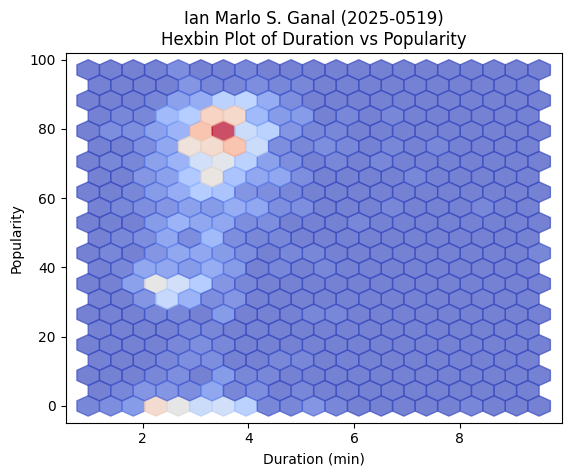

In [54]:
# 18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show() 

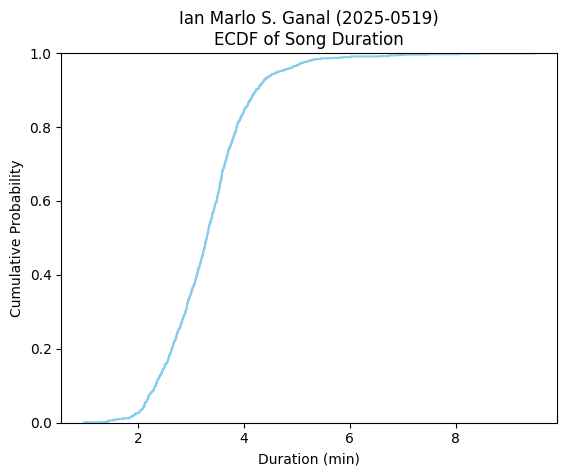

In [55]:
# 19
sns.ecdfplot(data=df, x='duration_min', color=color1) 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show() 

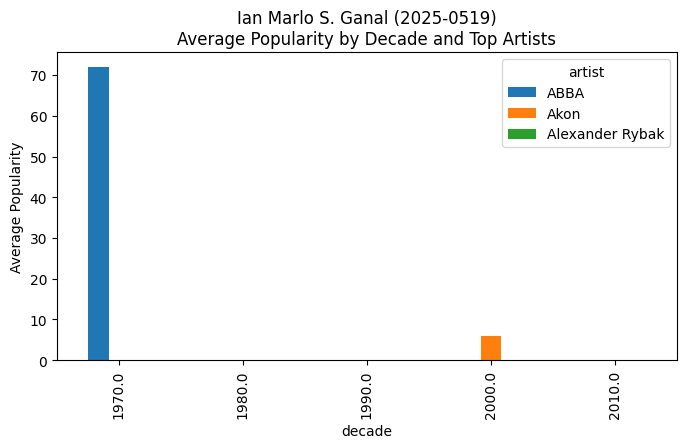

In [56]:
# 20
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')

df['decade'] = (df['release_date'] // 10) * 10

avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0) 
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4)) 
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists") 
plt.ylabel('Average Popularity') 
plt.show()
